# 📘 K-Nearest Neighbors (KNN) – Complete Theory

## 1. Introduction
- **K-Nearest Neighbors (KNN)** is a **supervised machine learning algorithm** used for **classification** and sometimes **regression**.
- It is a **lazy learning algorithm** → it does not build a model during training, instead it stores the dataset and makes decisions at prediction time.
- Core idea: A data point is classified based on the **majority class of its nearest neighbors**.

---

## 2. Key Concepts
### 🔹 Distance Metric
- To find "nearest neighbors," KNN uses distance measures:
  - **Euclidean Distance** (most common)
  - Manhattan Distance
  - Minkowski Distance
  - Hamming Distance (for categorical data)

### 🔹 K Value
- **K** = number of neighbors considered.
- Small K → sensitive to noise.
- Large K → smoother decision boundary but may ignore local patterns.

### 🔹 Voting
- For classification: Majority voting among neighbors.
- For regression: Average of neighbors’ values.

---

## 3. Working of KNN (Step by Step)
1. Choose the number of neighbors **K**.
2. Calculate the distance between the query point and all training points.
3. Select the **K nearest neighbors**.
4. For classification → assign the class with majority vote.  
   For regression → take the average of neighbors’ values.

---

## 4. Advantages of KNN
- Simple and intuitive.
- No training phase (lazy learner).
- Works well with small datasets.
- Can be used for both classification and regression.

---

## 5. Limitations of KNN
- Computationally expensive for large datasets (needs distance calculation for all points).
- Sensitive to irrelevant features and scaling.
- Choosing the right K is critical.
- Performance drops in high-dimensional data (curse of dimensionality).

---

## 6. Applications
- Recommendation systems.
- Text classification.
- Image recognition.
- Medical diagnosis.
- Credit scoring.

---

## 7. Example Intuition
- Suppose you want to classify whether a fruit is an **apple** or **orange**.
- You measure features like **weight** and **color**.
- If the new fruit is close to 3 apples and 2 oranges → KNN predicts **apple** (majority vote).

---

## 8. Summary
- **KNN = Classify based on neighbors.**
- **Distance metric** decides closeness.
- **K value** controls bias vs variance.
- Best suited for small datasets with clear boundaries.


In [18]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [5]:
data = pd.read_csv("diabetes.csv")

In [6]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [7]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1
1999,2,81,72,15,76,30.1,0.547,25,0


In [8]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [10]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
data.shape

(2000, 9)

In [11]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

<Axes: xlabel='Pregnancies', ylabel='count'>

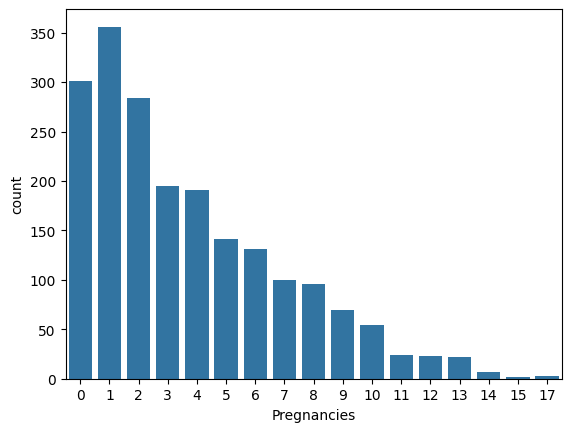

In [15]:
sns.countplot(x="Pregnancies",data = data)

<function matplotlib.pyplot.show(close=None, block=None)>

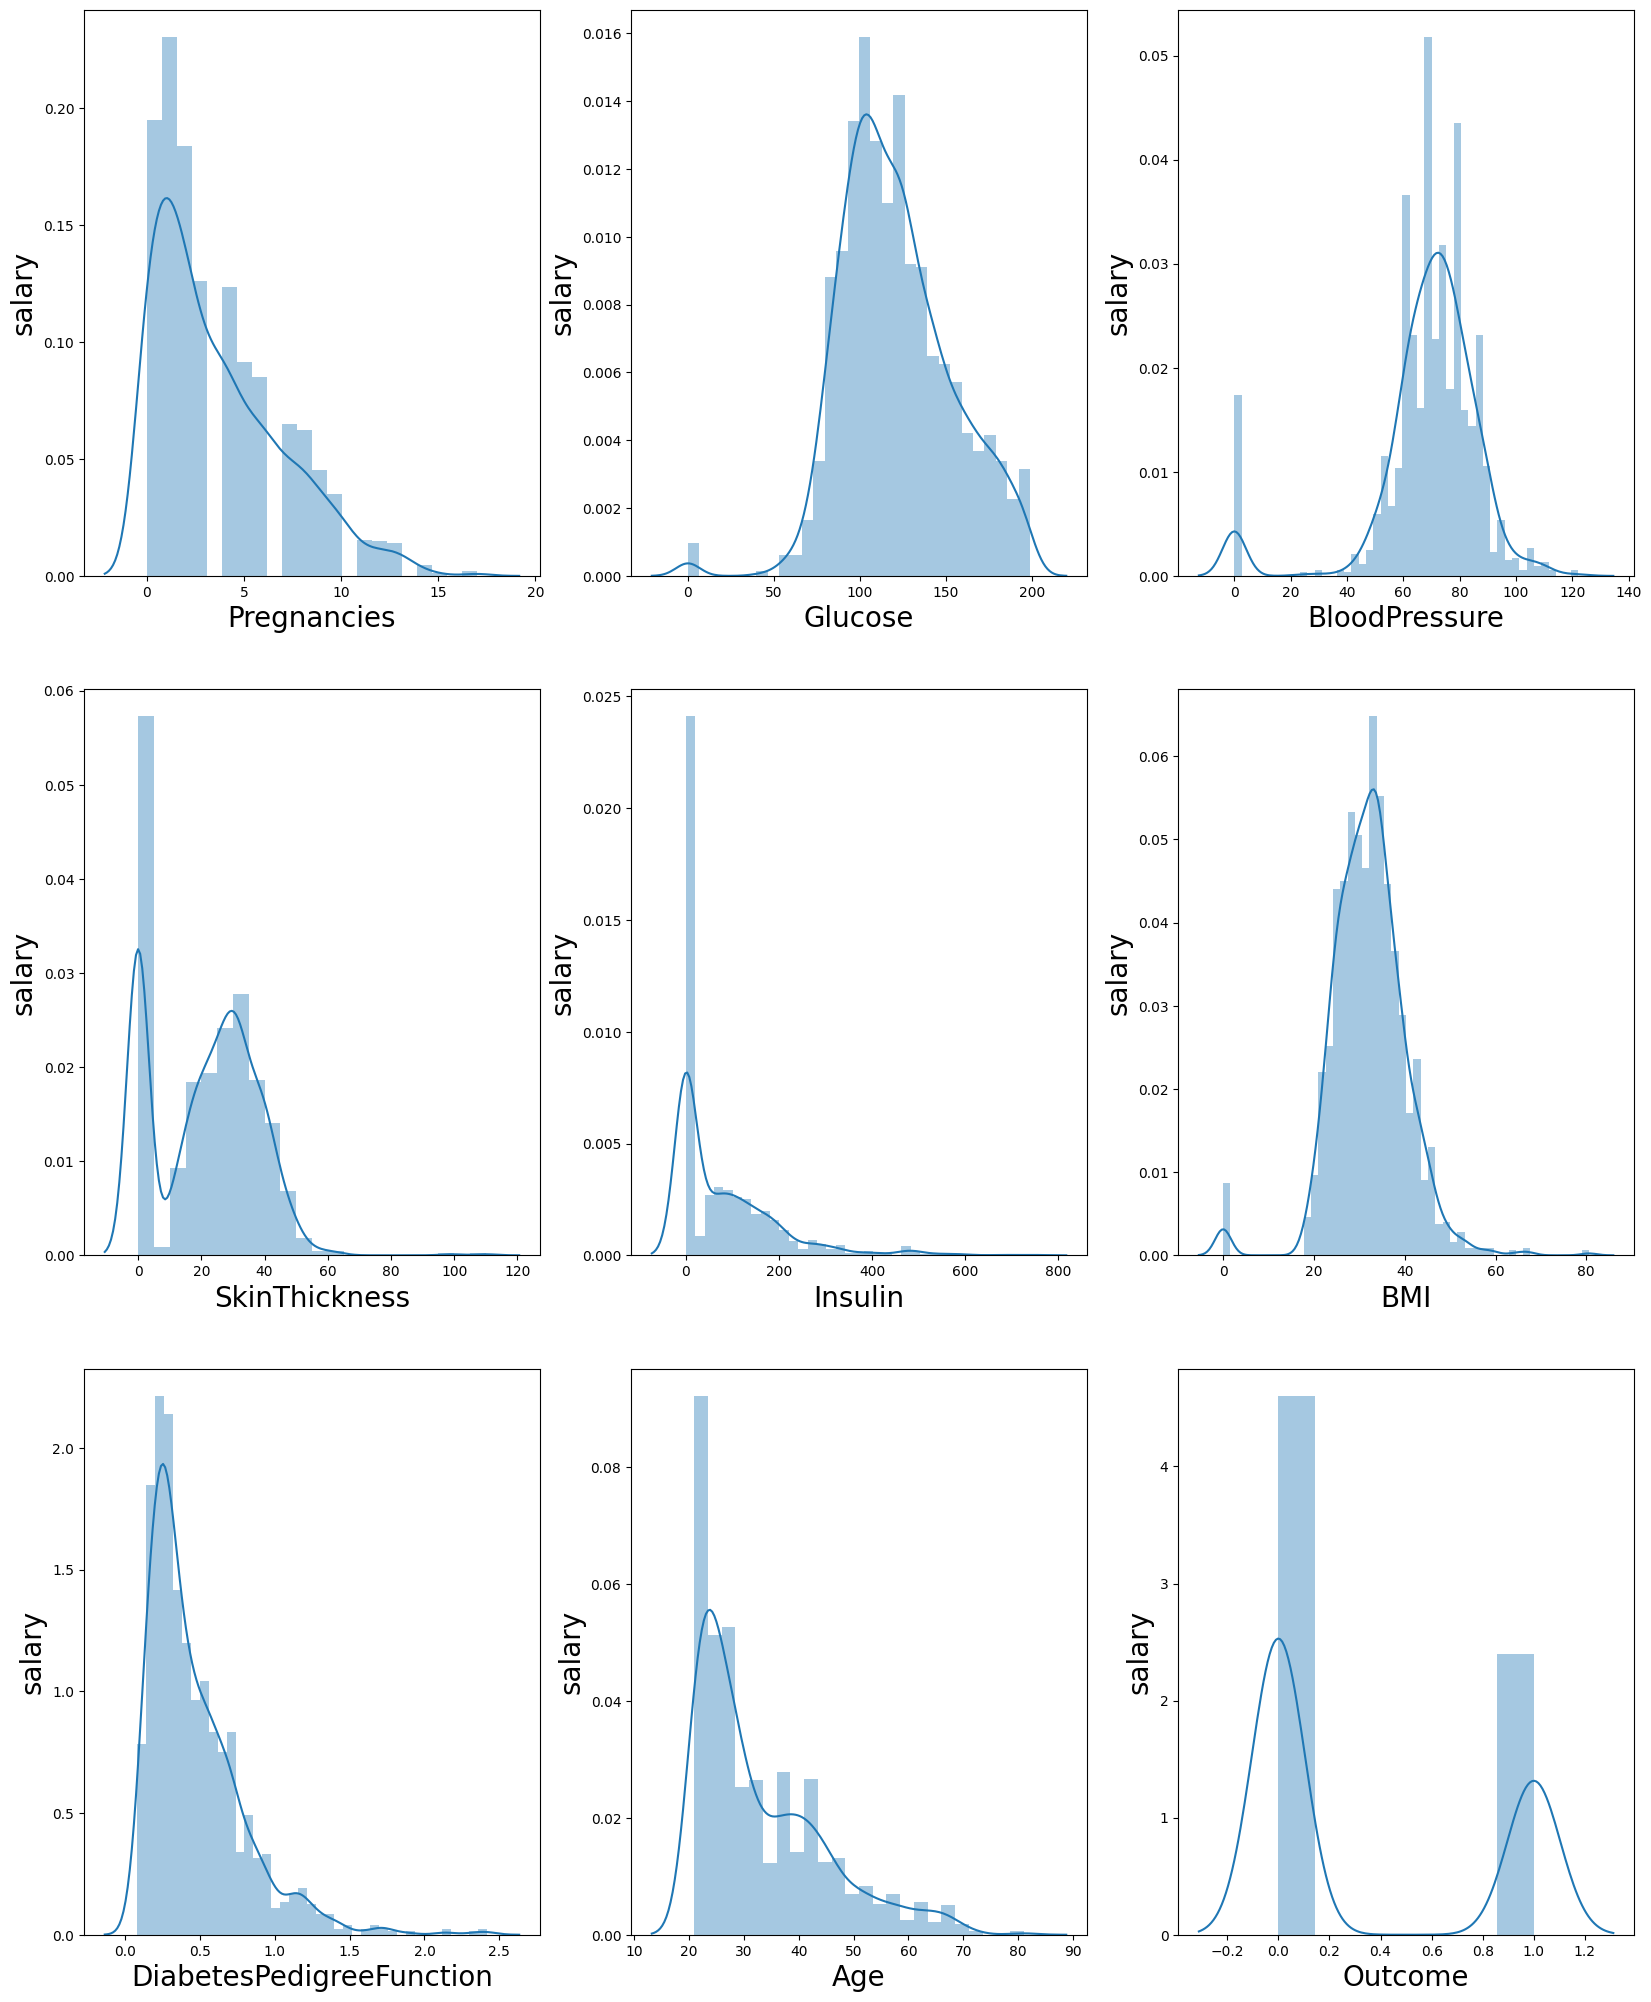

In [23]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber=1

for column in data:
  if plotnumber<=9:      #as there are 9 column in data 
    ax=plt.subplot(3,3,plotnumber)
    sns.distplot(data[column])
    plt.xlabel(column,fontsize=20)
    plt.ylabel('salary',fontsize=20)
  plotnumber+=1
plt.show

In [24]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [25]:
### Split X and Y
X = data[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']] ## Independent variable
y = data["Outcome"] ## Dependent or target varaible 

In [ ]:
## scaling the data
# scalar = StandardScaler

In [27]:
### Splitting the training and testing data
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)

In [29]:
model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [30]:
model.score(X_test,y_test)

0.7775

In [31]:
model.predict(X_test)

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,

In [32]:
y_predict = model.predict(X_test)

In [33]:
from sklearn.metrics import confusion_matrix,classification_report

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_predict))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_predict)
print(cm)

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       265
           1       0.68      0.64      0.66       135

    accuracy                           0.78       400
   macro avg       0.75      0.74      0.75       400
weighted avg       0.77      0.78      0.78       400


Confusion Matrix:
[[225  40]
 [ 49  86]]


<Axes: >

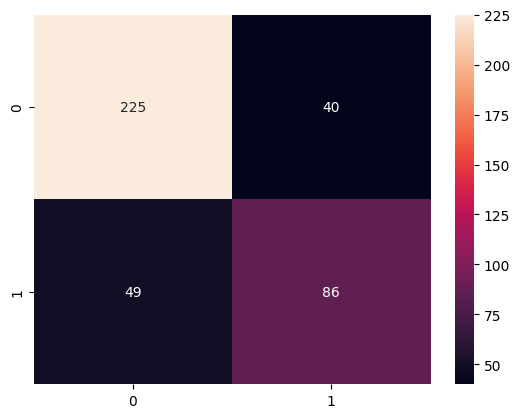

In [35]:
sns.heatmap(cm,annot=True,fmt='d')

In [36]:
sse = [] ## Sum of square error list form conversion
range=(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20)

In [37]:
for i in range:
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train,y_train)
  knn1=model.predict(X_test)
  sse.append(np.mean(knn1!=y_test))

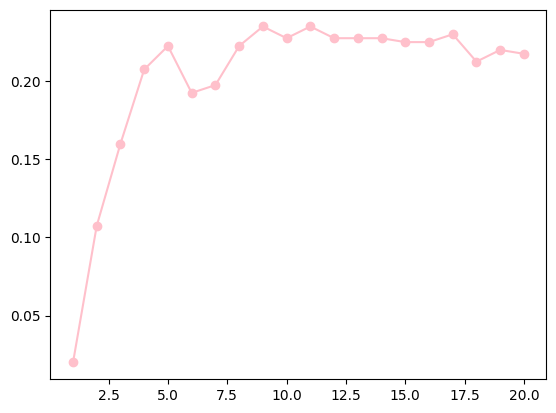

In [40]:
plt.plot(range,sse,marker='o',color='pink')

### SMOTE

In [ ]:

%pip install imblearn
%pip install -U imbalanced-learn

In [43]:
## Apply SMOTE to balance the data
from imblearn.over_sampling import SMOTE
smote = SMOTE() # object creation 

In [44]:
X_train_smote , y_train_smote = smote.fit_resample(X_train.astype('float'),y_train)

In [ ]:
## If you check  the smote is their otherwise don't used this code in main program  
from collections import Counter
print("Actual Classes",Counter(y_train))
print("SMOTE Classes",Counter(y_train_smote))

Actual Classes Counter({0: 1051, 1: 549})
SMOTE Classes Counter({1: 1051, 0: 1051})


In [46]:
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_smote,y_train_smote)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [47]:
## Predict the output for X_test
y_pred = knn2.predict(X_test)

In [49]:
print("classification_report")
print(classification_report(y_test,y_pred))

classification_report
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       265
           1       0.67      0.79      0.73       135

    accuracy                           0.80       400
   macro avg       0.78      0.80      0.78       400
weighted avg       0.81      0.80      0.80       400



In [50]:
print("Confusion Matrix")
cm = confusion_matrix(y_test,y_pred)
print(cm)

Confusion Matrix
[[212  53]
 [ 28 107]]


<Axes: >

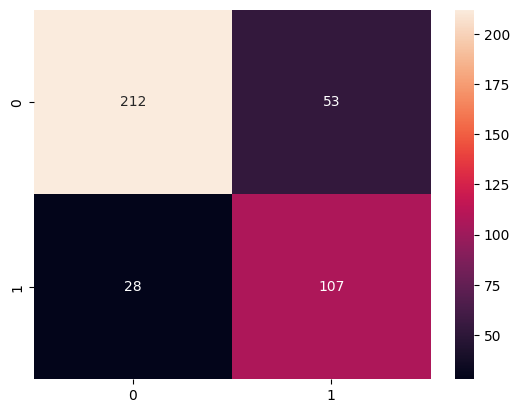

In [52]:
sns.heatmap(cm,annot=True,fmt='d')

In [53]:
data.shape

(2000, 9)